In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Modules
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)

# Set style for plots
sns.set(style="whitegrid")

In [ ]:
# Load Heart Disease dataset
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)

# Display the first few rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# 1. Separate Features (X) and Target (y)
X = df.drop('target', axis=1)
y = df['target']

# 2. Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Initialize SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Set up 10-Fold Cross-Validation
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Run Cross-Validation
cv_scores_svm = cross_val_score(svm_model, X_scaled, y, cv=kfold, scoring='accuracy')

print("--- SVM K-Fold Cross-Validation Results ---")
print(f"Average Accuracy: {cv_scores_svm.mean() * 100:.2f}%")

--- SVM K-Fold Cross-Validation Results ---
Average Accuracy: 83.49%


In [ ]:
# Train the model
svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Print metrics
print("--- SVM Detailed Performance Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_svm):.4f}")

--- SVM Detailed Performance Metrics ---
Accuracy:  0.8689
Precision: 0.8750
Recall:    0.8750
F1 Score:  0.8750


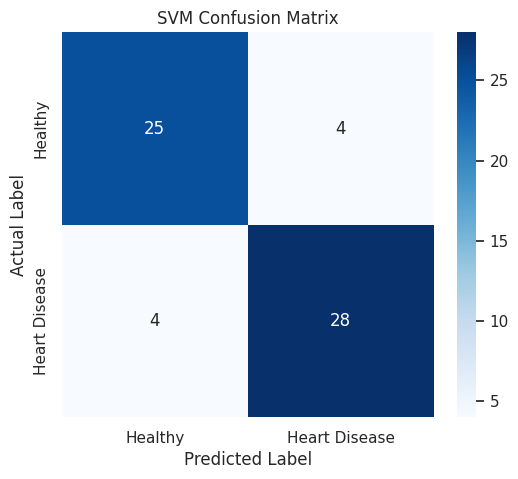

In [ ]:
# Create Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('SVM Confusion Matrix')
plt.show()